In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv(r"C:\Users\HP\Desktop\Bacancy\AI_ML\Deep_Learning\NLP\Task1\sample.csv")

In [3]:
df.drop(columns="Unnamed: 0",inplace=True)

## PREPROCESSING STEPS 

In [13]:
## remove the duplicates 
print("TOTAL DUPLICATES:",df.duplicated().sum())
df = df.drop_duplicates(subset='content')
print(f"After dedup: {len(df)} records")

TOTAL DUPLICATES: 350
After dedup: 406 records


In [14]:
df

,content,keywords
0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...
627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof)
630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)


In [16]:
df["keywords"].value_counts()

keywords
Prejudiciële bevoegheid (Grondwettelijk Hof)     258
Vernietigingsbevoegdheid (Grondwettelijk Hof)    148
Name: count, dtype: int64

## DETECT LANGUAGE FROM EACH DOCUMENT

In [17]:
from lingua import Language, LanguageDetectorBuilder

detector = LanguageDetectorBuilder.from_languages(
    Language.FRENCH, Language.DUTCH, Language.GERMAN
).build()

def detect_lang(text):
    result = detector.detect_language_of(text[:500])
    return result.name if result else "UNKNOWN"

df['language'] = df['content'].apply(detect_lang)
print(df['language'].value_counts())

language
DUTCH     149
FRENCH    135
GERMAN    122
Name: count, dtype: int64


In [20]:
content = df["content"].astype(str)
lengths = content.str.len()
tokens_est = lengths / 4.0

print(f"Total records (after dedup): {len(df)}")
print(f"Average text length: {lengths.mean():,.2f} characters")
print(f"Min text length: {lengths.min():,} characters")
print(f"Max text length: {lengths.max():,} characters")
print(f"Estimated avg tokens: {tokens_est.mean():,.2f} tokens")
print(f"Records < 512 tokens: {(tokens_est < 512).sum()} / {len(df)} ({(tokens_est < 512).mean()*100:.1f}%)")
print(f"Records > 512 tokens: {(tokens_est > 512).sum()} / {len(df)} ({(tokens_est > 512).mean()*100:.1f}%)")


Total records (after dedup): 406
Average text length: 21,943.15 characters
Min text length: 1,179 characters
Max text length: 65,535 characters
Estimated avg tokens: 5,485.79 tokens
Records < 512 tokens: 2 / 406 (0.5%)
Records > 512 tokens: 404 / 406 (99.5%)


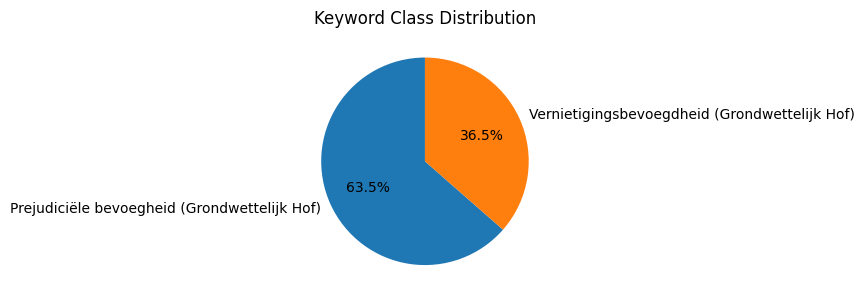

In [28]:

counts = df["keywords"].value_counts()

plt.figure(figsize=(8, 8))
counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Keyword Class Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [31]:
df1 = pd.read_csv("sample.csv", encoding="utf-8")   # try first
# or
# or
df3 = pd.read_csv("sample.csv", encoding="latin1")  # fallback


In [36]:
df

,content,keywords,language
0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),FRENCH
1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),DUTCH
2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),GERMAN
3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),FRENCH
4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),DUTCH
...,...,...,...
627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),FRENCH
628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),FRENCH
629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof),GERMAN
630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),FRENCH


In [37]:
df1

,Unnamed: 0,content,keywords
0,0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...,...
401,627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
402,628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
403,629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof)
404,630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)


In [38]:
df3

,Unnamed: 0,content,keywords
0,0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...,...
401,627,"""La Cour constitutionnelle,composC)e des prC)s...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)
402,628,"""La Cour constitutionnelle,composC)e des prC)s...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)
403,629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)
404,630,"""La Cour constitutionnelle,composC)e des prC)s...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)


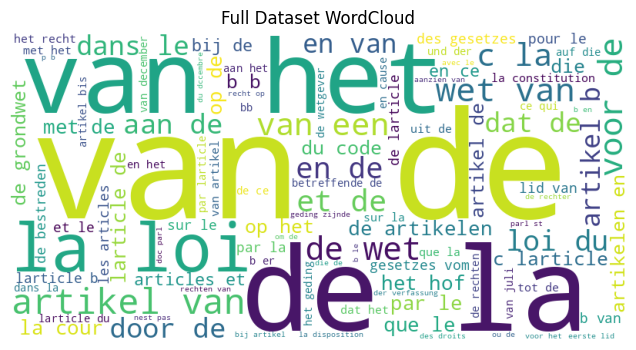

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

df = pd.read_csv("sample.csv")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_content"] = df["content"].apply(clean_text)

all_text = " ".join(df["clean_content"].tolist())

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(all_text)

plt.figure(figsize=(8,4))
plt.imshow(wc)
plt.axis("off")
plt.title("Full Dataset WordCloud")
plt.show()
